# Exploratory Data Analysis

Load subject data, investigate channel arrangement, data scale, etc

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import os
import pandas as pd

%matplotlib widget

plt.close('all')

In [2]:
# Load subject data

DATA_PATH = "/Volumes/LPM02 storage/Datasets/Bio/DaLiA/data/S2/S2.pkl"

with open(DATA_PATH, 'rb') as f:
    data = pkl.load(f, encoding='latin1')

In [3]:
# Print data dict keys

print(data.keys())

dict_keys(['rpeaks', 'signal', 'label', 'activity', 'questionnaire', 'subject'])


In [4]:
# Useful constants

fs_ppg = 64
fs_acc = 32
T_win = 8.0
stride = 2.0

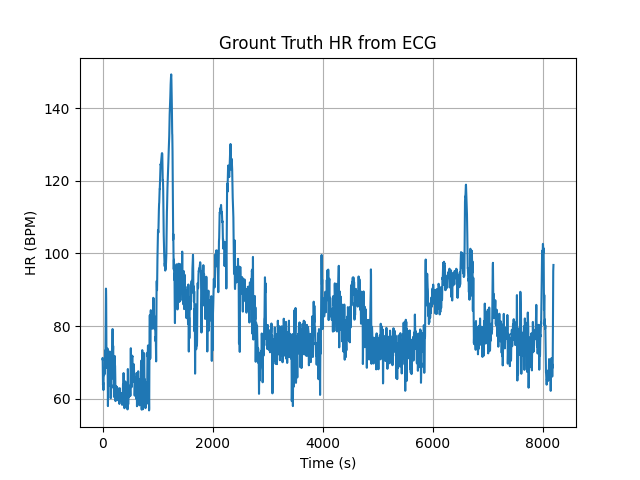

In [5]:
# Ground truth HR

hr_ref = data['label']
N = len(hr_ref)
t = np.arange(N) * 2
fig, ax = plt.subplots(1,1)
ax.plot(t, data['label'])
ax.set_xlabel('Time (s)')
ax.set_ylabel('HR (BPM)')
ax.set_title('Grount Truth HR from ECG')
ax.grid(True)
plt.show()

Raw PPG total samples: 525120
Raw PPG total time:    8205.0


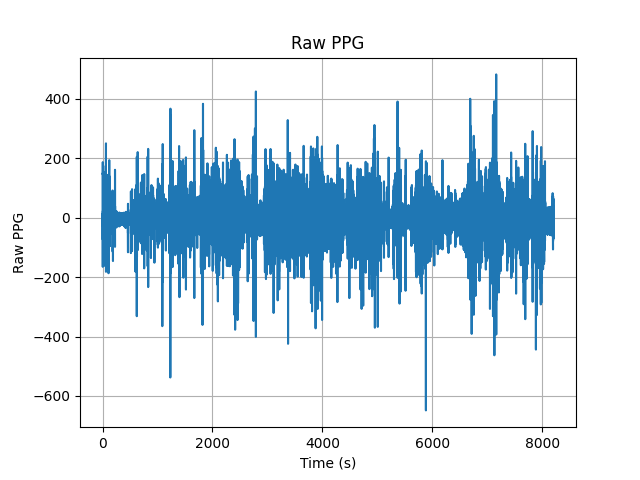

In [6]:
# PPG data (BVP): fs = 64 Hz

ppg_raw = data['signal']['wrist']['BVP']

print(f"Raw PPG total samples: {len(ppg_raw)}")
print(f"Raw PPG total time:    {len(ppg_raw) / fs_ppg}")

fig, ax = plt.subplots()
ax.plot(np.arange(len(ppg_raw)) / fs_ppg, ppg_raw)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Raw PPG')
ax.set_title('Raw PPG')
ax.grid(True)
plt.show()

Raw ACC total samples: 262560
Raw ACC total time:    8205.0


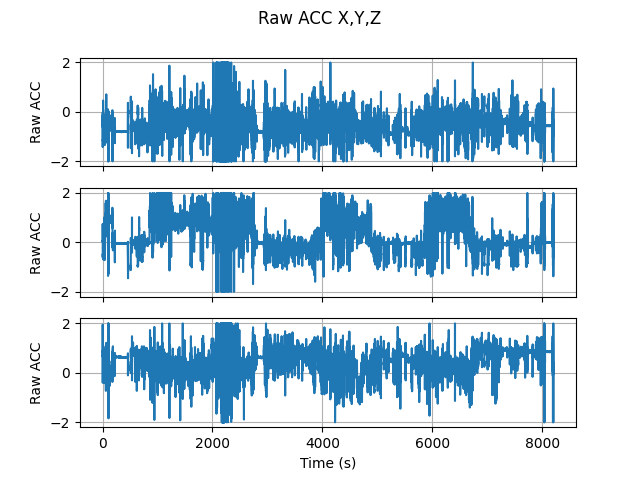

In [7]:
# Accel data: fs = 32 Hz

acc_raw = data['signal']['wrist']['ACC']

print(f"Raw ACC total samples: {len(acc_raw)}")
print(f"Raw ACC total time:    {len(acc_raw) / fs_acc}")

fig, ax = plt.subplots(3, 1, sharex=True)
ax[0].plot(np.arange(len(acc_raw)) / fs_acc, acc_raw[:,0])
ax[1].plot(np.arange(len(acc_raw)) / fs_acc, acc_raw[:,1])
ax[2].plot(np.arange(len(acc_raw)) / fs_acc, acc_raw[:,2])
ax[2].set_xlabel('Time (s)')
for axi in ax:
    axi.set_ylabel('Raw ACC')
    axi.grid(True)
plt.suptitle('Raw ACC X,Y,Z')
plt.show()


In [8]:
# Preprocessing: Samplerate matching
#
# For HR estimation, Bandpass Filter (BPF) will be applied to keep only 0.4 - 4 Hz (24 - 240 BPM)
# This means we can downsample both PPG and ACC -> 16 Hz Samplerate; 8 Hz now Nyquist
# But larger dt = 1 / fs means larger error in a time domain HR estimation function
# Therefore, downsample PPG to match ACC fs

from scipy.signal import decimate

FS = 32
ppg_res = decimate(ppg_raw, fs_ppg // FS, axis=0)
acc_res = decimate(acc_raw, fs_acc // FS, axis=0)

print('Resampled total samples:')
print(f"   ppg: {len(ppg_res)}")
print(f"   acc: {len(acc_res)}")

Resampled total samples:
   ppg: 262560
   acc: 262560


/var/folders/bq/csqgvczj6jndm459wzs6n4kw0000gn/T/ipykernel_9030/484910578.py:18: RuntimeWarning: divide by zero encountered in log10
  ax[0].plot(w, 20 * np.log10(np.abs(h)))


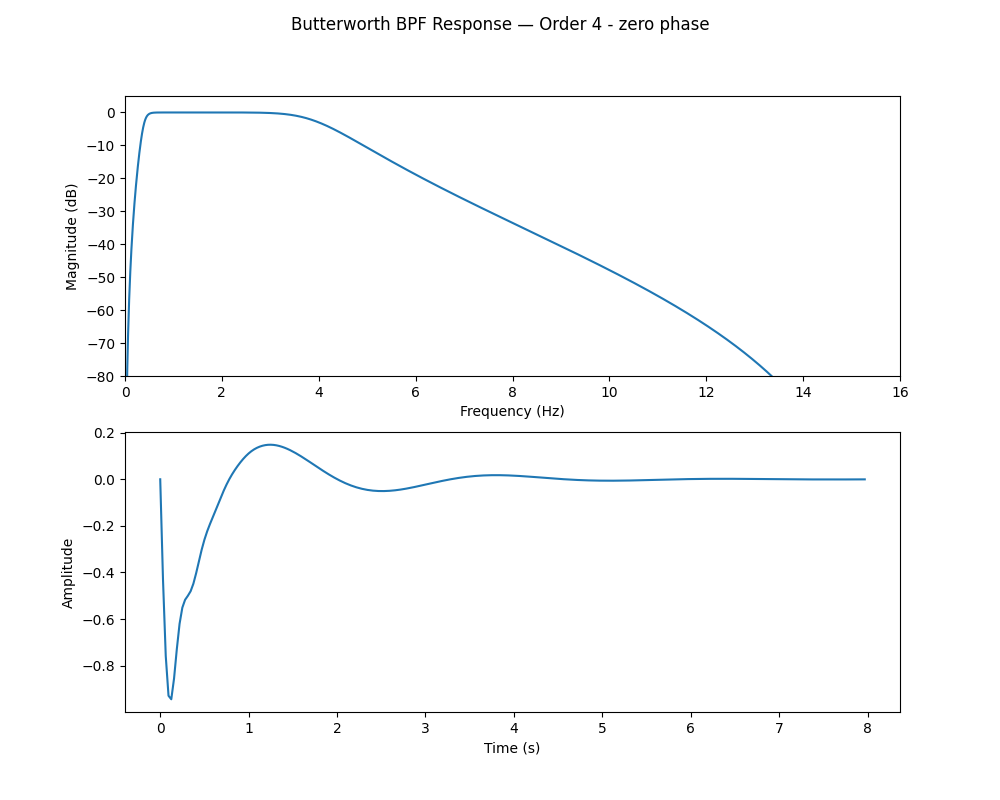

In [9]:
# Preprocessing: Bandpass Filter Design
#
# For HR estimation, keep only 0.4 - 4 Hz (24 - 240 BPM)
# 4th order Butterworth, since this is offline, use sosfiltfilt for zero phase

from scipy.signal import butter, sosfiltfilt, sosfreqz

sos = butter(4, [0.4, 4.0], btype='bandpass', fs=FS, output='sos')

# Filter freq and impulse response
w, h = sosfreqz(sos, worN=2048, fs=FS)
impulse = np.zeros(256)
impulse[0] = 1.0
h_imp = sosfiltfilt(sos, impulse)
t_imp = np.arange(len(impulse)) / FS

fig, ax = plt.subplots(2, 1, figsize=(10,8))
ax[0].plot(w, 20 * np.log10(np.abs(h)))
ax[0].set_xlim(0, FS / 2)
ax[0].set_ylim(-80, 5)
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Magnitude (dB)')
ax[1].plot(t_imp, h_imp)
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Amplitude')
plt.suptitle('Butterworth BPF Response — Order 4 - zero phase')
plt.show()

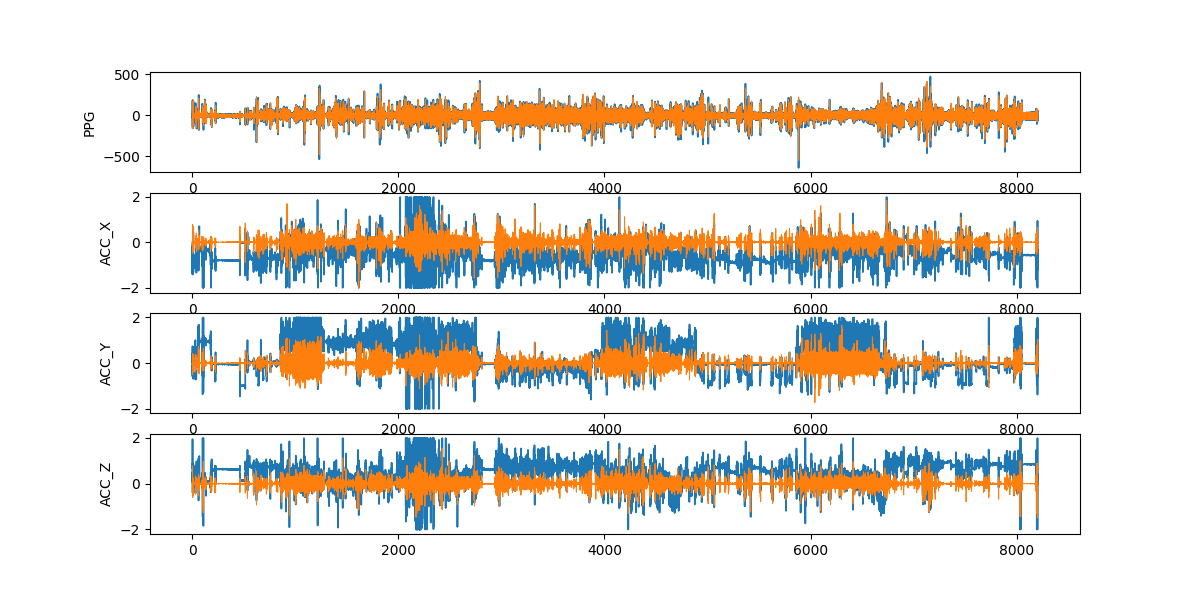

In [10]:
# Preprocessing: Bandpass Filter Application

ppg_filt = sosfiltfilt(sos, ppg_res, axis=0)
acc_filt = sosfiltfilt(sos, acc_res, axis=0)

# Plot filtered vs "raw" signals
t = np.arange(len(ppg_filt)) / FS
fig, ax = plt.subplots(4, 1, figsize=(12,6))
ax[0].plot(t, ppg_res, lw=1.25)
ax[0].plot(t, ppg_filt, lw=0.75)
ax[0].set_ylabel('PPG')
ax[1].plot(t, acc_raw[:, 0], lw=1.25)
ax[1].plot(t, acc_filt[:, 0], lw=0.75)
ax[1].set_ylabel('ACC_X')
ax[2].plot(t, acc_raw[:, 1], lw=1.25)
ax[2].plot(t, acc_filt[:, 1], lw=0.75)
ax[2].set_ylabel('ACC_Y')
ax[3].plot(t, acc_raw[:, 2], lw=1.25)
ax[3].plot(t, acc_filt[:, 2], lw=0.75)
ax[3].set_ylabel('ACC_Z')
plt.show()

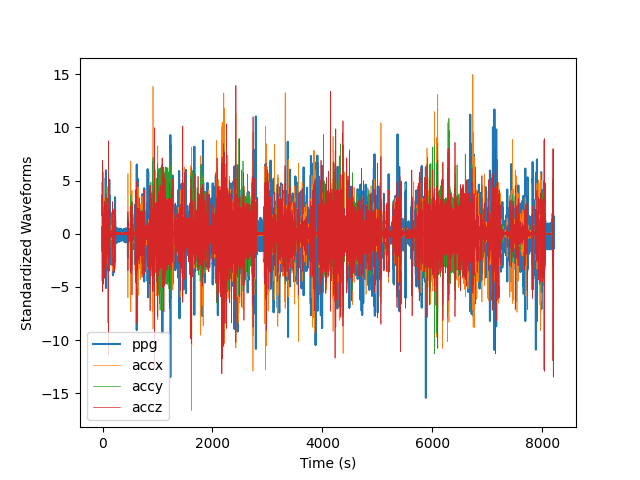

In [11]:
# Normalization
#
# Convert all data to 0 mean, unit std

ppg_norm = (ppg_filt - np.mean(ppg_filt)) / np.std(ppg_filt)
acc_norm = (acc_filt - np.mean(acc_filt, axis=0)) / np.std(acc_filt, axis=0)

# Plot
fix, ax = plt.subplots(1,1)
ax.plot(t, ppg_norm, lw = 1.5, label='ppg')
ax.plot(t, acc_norm[:, 0], lw = 0.5, label='accx')
ax.plot(t, acc_norm[:, 1], lw = 0.5, label='accy')
ax.plot(t, acc_norm[:, 2], lw = 0.5, label='accz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Standardized Waveforms')
ax.legend()
plt.show()

## EDA Notes:
- Acc channels clipped to +/- 2
    - data cleans up with preprocessing